# Landmark Alignment

This notebook implements face-centric alignment so that the eyes and mouth are in the same position across frames. This is done by detecting facial landmarks and applying an affine transformation to align the faces. This removes "camera shake" and head movement from the dataset and can help the model focus on the relevant facial features/artifacts (e.g., eye blinking, mouth movement, lip-sync flickers) and improve performance on deepfake detection tasks.

##### Import libraries

In [ ]:
# %rehashx
import cv2
import torch.nn as nn
import mediapipe as mp
import torch.optim as optim
from mediapipe.tasks.python import vision
from mediapipe.tasks import python as mp_python

import os
import sys
import h5py
import torch
import logging
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.transforms as T
import torchaudio.transforms as transforms
from torch.utils.data import Dataset, DataLoader

curr_dir = os.getcwd()
root_dir = os.path.dirname(curr_dir)
data_dir = os.path.join(root_dir, 'data')

if root_dir not in sys.path:
	sys.path.append(root_dir)

import aceverify

# Setting HuggingFace token for accessing pretrained models faster
os.environ['HF_HOME'] = os.path.join(root_dir, 'huggingface')
os.environ['HF_TOKEN'] = "" # TODO: Update with your HuggingFace token

/rhome/abhar061/bigdata/.conda/envs/aceverify/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### Initializing MediaPipe Face Mesh

In [2]:
# Download Face Landmarker model once
import urllib.request

model_dir = os.path.join(root_dir, 'models')
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, 'face_landmarker.task')

if not os.path.exists(model_path):
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task',
        model_path
    )

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = vision.FaceLandmarker
FaceLandmarkerOptions = vision.FaceLandmarkerOptions
VisionRunningMode = vision.RunningMode

options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=VisionRunningMode.IMAGE,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

face_landmarker = FaceLandmarker.create_from_options(options)

W0000 00:00:1774318627.620924 2543622 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1774318627.644046 2543626 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774318627.654465 2543635 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Configure Logging in Aceverify module

In [18]:
def configure_logging(logger: logging.Logger, log_level: str = "INFO", force: bool = False):
    numeric_level = getattr(logging, log_level.upper(), logging.INFO)
    logging.basicConfig(
        level=numeric_level,
        format="%(asctime)s | %(levelname)s | %(filename)s:%(lineno)d | %(funcName)s | %(message)s",
        force=force,
    )
    logging.getLogger().setLevel(numeric_level)
    logger.setLevel(numeric_level)

logger = logging.getLogger(__name__)
configure_logging(logger)

##### Utility function to get alignment matrix

In [3]:
def get_alignment_matrix(
    landmarks,
    image_size=(224, 224),
    left_eye_pos=(0.35, 0.4),
    right_eye_pos=(0.65, 0.4),
):
    """
    Compute affine transform that aligns eye corners to canonical positions.
    landmarks are normalized [0,1], so convert to pixel coordinates first.
    image_size = (width, height)
    """
    w, h = image_size

    # MediaPipe normalized landmarks -> pixel coordinates
    l_eye = np.array([landmarks[33].x * w, landmarks[33].y * h], dtype=np.float32)
    r_eye = np.array([landmarks[263].x * w, landmarks[263].y * h], dtype=np.float32)

    dX = r_eye[0] - l_eye[0]
    dY = r_eye[1] - l_eye[1]
    angle = np.degrees(np.arctan2(dY, dX))

    current_dist = np.hypot(dX, dY)
    desired_dist = (right_eye_pos[0] - left_eye_pos[0]) * w

    if current_dist < 1e-6:
        return np.array([[1, 0, 0], [0, 1, 0]], dtype=np.float32)

    scale = desired_dist / current_dist
    eye_center = ((l_eye[0] + r_eye[0]) * 0.5, (l_eye[1] + r_eye[1]) * 0.5)

    M = cv2.getRotationMatrix2D(eye_center, angle, scale)

    # Move eyes to desired canonical positions
    t_x = w * 0.5
    t_y = h * left_eye_pos[1]
    M[0, 2] += (t_x - eye_center[0])
    M[1, 2] += (t_y - eye_center[1])

    return M.astype(np.float32)

##### Utility function to align face frame

In [30]:
def align_face_frame(frame_rgb, target_size=(224, 224)):
    """
    frame_rgb: HxWx3 RGB uint8/float
    Returns aligned RGB image.
    """
    if frame_rgb.ndim != 3 or frame_rgb.shape[2] != 3:
        raise ValueError(f"Expected HxWx3 image, got {frame_rgb.shape}")

    # Normalize dtype for MediaPipe
    if frame_rgb.dtype != np.uint8:
        if frame_rgb.max() <= 1.0:
            frame_rgb = (np.clip(frame_rgb, 0.0, 1.0) * 255).astype(np.uint8)
        else:
            frame_rgb = np.clip(frame_rgb, 0, 255).astype(np.uint8)

    h, w, _ = frame_rgb.shape
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
    result = face_landmarker.detect(mp_image)

    print(f"Detected {len(result.face_landmarks)} faces in the image")

    if not result.face_landmarks:
        return cv2.resize(frame_rgb, target_size)

    M = get_alignment_matrix(result.face_landmarks[0], image_size=(w, h))
    aligned_rgb = cv2.warpAffine(frame_rgb, M, target_size, flags=cv2.INTER_CUBIC)
    return aligned_rgb

##### Utility function for comparison plot

In [31]:
def show_alignment_impact(raw_rgb, aligned_rgb):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(raw_rgb)
    ax[0].set_title("Raw Frame (Unstable Pose)")
    ax[0].axis("off")

    ax[1].imshow(aligned_rgb)
    ax[1].set_title("Aligned Face (Stable Features)")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()

Media directory: /bigdata/mxwanglab/shared/ace_verify/media
clip path: /bigdata/mxwanglab/shared/ace_verify/media/unauthentic_news.mp4
Extracted 294 frames from the video.
Detected 1 faces in the image


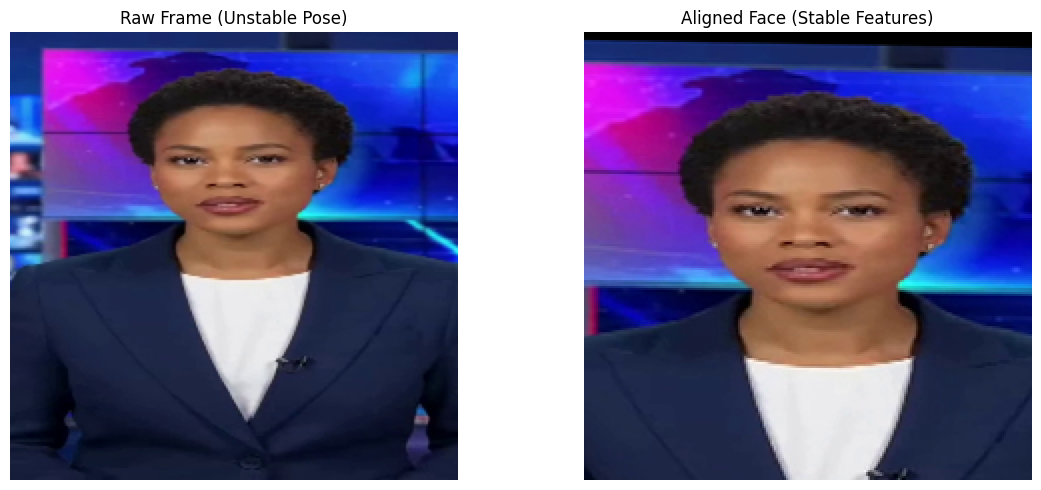

In [ ]:
media_dir = os.path.join(root_dir, 'frontend', 'static')
print(f"Media directory: {media_dir}")
# clip_path = os.path.join(media_dir, 'gan_portrait.mp4')
# clip_path = os.path.join(media_dir, 'faceswap_clip.mp4')
# clip_path = os.path.join(media_dir, 'lip-sync_fake.mp4')
# clip_path = os.path.join(media_dir, 'political_speech.mp4')
clip_path = os.path.join(media_dir, 'unauthentic_news.mp4')

print(f"clip path: {clip_path}")

# Reading video frames
cap = cv2.VideoCapture(clip_path)
frames = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(frame)
cap.release()
print(f"Extracted {len(frames)} frames from the video.")

# Aligning the first frame
raw_frame = (frames[0].astype(np.float32)) / 255.0 # Normalize to float of range [0,1] in numpy
raw_frame = cv2.cvtColor(raw_frame, cv2.COLOR_BGR2RGB) # Convert BGR to RGB
raw_frame = cv2.resize(raw_frame, (224, 224)) # resize image to (224x224)

aligned_frame = align_face_frame(raw_frame)
show_alignment_impact(raw_frame, aligned_frame)

In [29]:
raw_frame.shape

(1280, 704, 3)

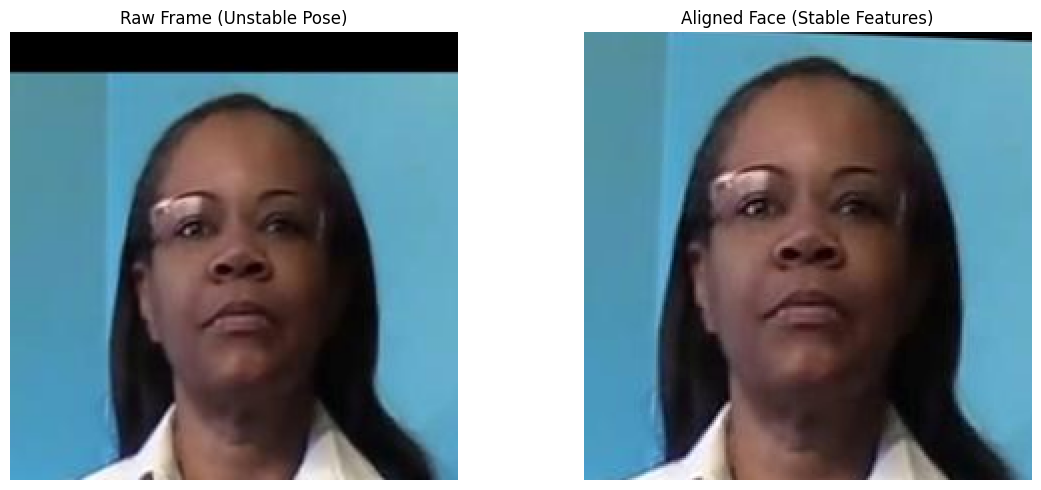

In [23]:
test_data_path = os.path.join(data_dir, "test_data.h5")
test_loader = aceverify.ACEDataset(h5_path=test_data_path, is_training=False)

# Pick Random Image
rand_ind = np.random.randint(len(test_loader))
video, *_ = test_loader[rand_ind]                                   # [C, T, H, W]
first_frame = video[:, 0, :, :]                                    # [C, H, W]
original_video_frame = first_frame.permute(1, 2, 0).cpu().numpy()  # RGB float [0,1]
aligned_video_frame = align_face_frame(original_video_frame)

show_alignment_impact(original_video_frame, aligned_video_frame)

In [33]:
original_video_frame.shape

(224, 224, 3)

##### Running the pipeline

In [6]:
test_data_path = os.path.join(data_dir, "test_data.h5")
test_loader = aceverify.ACEDataset(h5_path=test_data_path, is_training=False)

# Pick Random Image
rand_ind = np.random.randint(len(test_loader))
video, *_ = test_loader[rand_ind]                                   # [C, T, H, W]
first_frame = video[:, 0, :, :]                                    # [C, H, W]
original_video_frame = first_frame.permute(1, 2, 0).cpu().numpy()  # RGB float [0,1]

aligned_video_frame = align_face_frame(original_video_frame)

##### Comparison against original frame

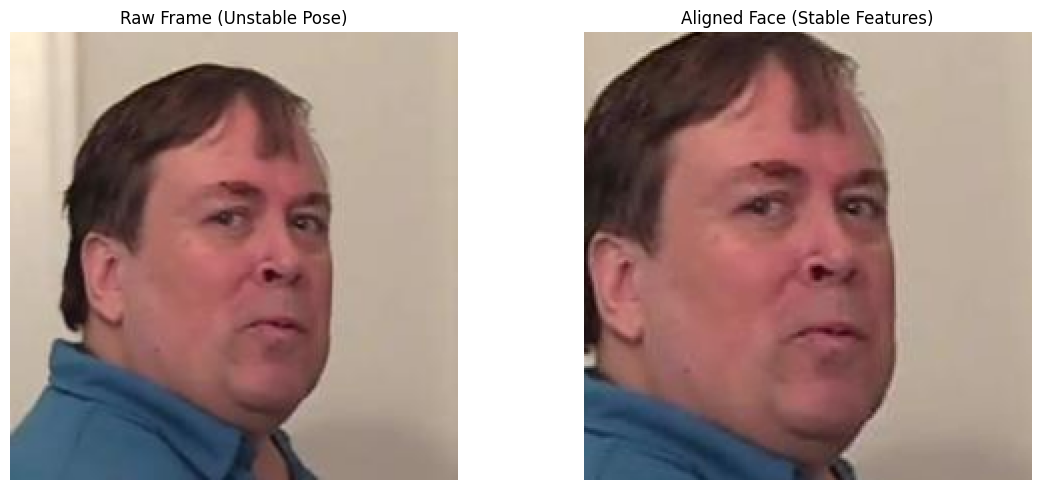

In [7]:
show_alignment_impact(original_video_frame, aligned_video_frame)

##### Model Performance Comparison

Custom Dataset class with Landmark Alignment

In [15]:
class ACEDataset_with_Landmark_Alignment(aceverify.ACEDataset):
    def __init__(self, h5_path, indices=None, is_training=False, face_model_path=None):
        super().__init__(h5_path, indices, is_training)
        self.face_model_path = face_model_path or model_path
        self._face_landmarker = None
    
    def _get_face_landmarker(self):
        if self._face_landmarker is None:
            BaseOptions = mp.tasks.BaseOptions
            FaceLandmarker = vision.FaceLandmarker
            FaceLandmarkerOptions = vision.FaceLandmarkerOptions
            VisionRunningMode = vision.RunningMode

            options = FaceLandmarkerOptions(
                base_options=BaseOptions(model_asset_path=self.face_model_path),
                running_mode=VisionRunningMode.IMAGE,
                num_faces=1,
                min_face_detection_confidence=0.5,
                min_face_presence_confidence=0.5,
                min_tracking_confidence=0.5,
            )
            self._face_landmarker = FaceLandmarker.create_from_options(options)
        return self._face_landmarker

    def _align_frame(self, frame_rgb_uint8, target_size=(224, 224)):
        landmarker = self._get_face_landmarker()

        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb_uint8)
        result = landmarker.detect(mp_image)

        if not result.face_landmarks:
            return cv2.resize(frame_rgb_uint8, target_size)

        h, w, _ = frame_rgb_uint8.shape
        M = get_alignment_matrix(result.face_landmarks[0], image_size=(w, h))
        aligned = cv2.warpAffine(
            frame_rgb_uint8,
            M,
            target_size,
            flags=cv2.INTER_CUBIC,
            borderMode=cv2.BORDER_REFLECT_101, # NOTE : REFLECT border avoids black-corner artifacts in training data
        )
        return aligned

    def __getitem__(self, idx):
        if self.file is None:
            self.file = h5py.File(self.h5_path, "r")
            self.keys = list(self.file.keys())

        real_idx = self.indices[idx]
        key = self.keys[real_idx]
        group = self.file[key]

        full_video = group["video"][:]  # [T, H, W, C] uint8
        total_frames = full_video.shape[0]
        num_output_frames = 16
        stride = 2
        frame_indices = np.arange(0, num_output_frames * stride, stride)
        if frame_indices[-1] >= total_frames:
            frame_indices = np.linspace(0, total_frames - 1, num_output_frames).astype(int)

        selected_frames = full_video[frame_indices]  # [T, H, W, C]
        aligned_frames = [self._align_frame(frame, target_size=(224, 224)) for frame in selected_frames]
        aligned_np = np.stack(aligned_frames, axis=0)  # [T, H, W, C]

        video = torch.from_numpy(aligned_np).float().permute(3, 0, 1, 2) / 255.0  # [C, T, H, W]

        aug = T.Compose([
            T.ColorJitter(brightness=0.2, contrast=0.2),
            T.RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0),
        ])
        if self.is_training:
            video = torch.stack([aug(frame) for frame in video.permute(1, 0, 2, 3)]).permute(1, 0, 2, 3)

        audio = torch.from_numpy(group["audio"][:]).float()
        if audio.ndim > 1:
            audio = audio.mean(dim=0)
        spec = self.spectrogram_transform(audio).unsqueeze(0)
        spec = F.interpolate(spec.unsqueeze(0), size=(224, 224), mode="bilinear", align_corners=False).squeeze(0)

        label = torch.tensor(group.attrs["label"], dtype=torch.long)
        return video, spec, label

    def __del__(self):
        try:
            if self._face_landmarker is not None:
                self._face_landmarker.close()
        except Exception:
            pass
        super().__del__()

##### Global Setup & Utility Functions

In [9]:
results_log = {}

# Hyperparameters & Parameters for training
epochs = 10
batch_size = 8
learning_rate = 5e-5
train_path = f"{data_dir}/train_data-003.h5"
test_path = f"{data_dir}/test_data.h5"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.BCEWithLogitsLoss()

config = {
    "device":device,
    "criterion": criterion,
    "epochs": epochs,
    "batch_size": batch_size,
    "test_path": test_path,
    "train_path": train_path,
    "shuffle_data": True,
}

In [10]:
def fixed_balanced_indices(path, n, seed=42):
    rng = np.random.default_rng(seed)
    with h5py.File(path, "r") as f:
        labels = np.array([f[k].attrs["label"] for k in f.keys()])

    real_indices = np.where(labels == 0)[0]
    fake_indices = np.where(labels == 1)[0]
    num_each = n // 2

    sel_real = rng.choice(real_indices, min(len(real_indices), num_each), replace=False)
    sel_fake = rng.choice(fake_indices, min(len(fake_indices), num_each), replace=False)

    indices = np.concatenate([sel_real, sel_fake])
    rng.shuffle(indices)
    return indices

In [11]:
SEED = 42

# Fetching common Test Indices for fair comparison amongst all the models
test_n = 200
test_indices = fixed_balanced_indices(test_path, test_n, seed=SEED)
config["test_indices"] = test_indices

In [12]:
results_dir = os.path.join(root_dir, "results")
os.makedirs(results_dir, exist_ok=True)

def plot_comparison(results):
    sns.set_style("white")
    plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
    
    fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
    
    # Color palette
    colors = sns.color_palette("Set1", n_colors=len(results))
    
    for i, (experiment_name, metrics) in enumerate(results.items()):
        color = colors[i]
        epochs = metrics['epochs']
        
        # Plotting Test Accuracy with Solid Line (-) as it's the Primary Focus
        ax.plot(epochs, metrics['test_accuracies'], 
                label=f"{experiment_name} (Test: {max(metrics['test_accuracies']):.1f}%)", 
                color=color, linestyle='-', linewidth=2.5)
        
        # Plotting Train Accuracy with Dashed Line (--) as it's Secondary Focus
        ax.plot(epochs, metrics['train_accuracies'], 
                label=f"{experiment_name} (Train: {max(metrics['train_accuracies']):.1f}%)", 
                color=color, linestyle='--', linewidth=1.5, alpha=0.7)
        
        # Marking the peak test accuracy
        best_acc = max(metrics['test_accuracies'])
        best_epoch = epochs[metrics['test_accuracies'].index(best_acc)]
        ax.scatter(best_epoch, best_acc, color=color, s=40, edgecolors='black', zorder=5)

    # Labeling and Titles
    ax.set_title("Performance gain from Landmark Alignment Technique", fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel("Epochs", fontsize=14)
    ax.set_ylabel("Accuracy (%)", fontsize=14)
    
    # Refined Legend
    ax.legend(loc='lower right', frameon=True, fontsize=10, ncol=1)
    
    # Grid and Spines
    ax.grid(True, linestyle='--', alpha=0.6)
    sns.despine() # Removes top and right borders
    
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, "landmark_alignment_comparison.pdf"), format='pdf', bbox_inches='tight') # Best for LaTeX
    plt.show()

##### Training the models

Baseline

In [13]:
baseline_model = aceverify.ACEVerifyModel().to(device)
optimizer = optim.AdamW(baseline_model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
checkpoint_path = "aceverify_baseline_final.pth"

config["model"] = baseline_model
config["optimizer"] = optimizer
config["scheduler"] = scheduler
config["checkpoint_path"] = checkpoint_path
config["dataset_class"] = aceverify.ACEDataset

if os.path.exists(checkpoint_path):
    print(f"Loading trained model from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    baseline_model.load_state_dict(checkpoint)
    trained_baseline_model = baseline_model
    results_log["Baseline"] = pd.read_csv(checkpoint_path.replace('.pth', '_metrics.csv')).to_dict(orient='list')
else:
    trained_baseline_model, results_log["Baseline"] = aceverify.train_model(config)

No checkpoint found. Starting from pretrained ViT weights.


Landmark Alignment Model

In [ ]:
landmark_alignment_model = aceverify.ACEVerifyModel().to(device)
optimizer = optim.AdamW(landmark_alignment_model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
checkpoint_path = "aceverify_landmark_alignment_final.pth"

config["model"] = landmark_alignment_model
config["optimizer"] = optimizer
config["scheduler"] = scheduler
config["checkpoint_path"] = checkpoint_path
config["dataset_class"] = ACEDataset_with_Landmark_Alignment

if os.path.exists(checkpoint_path):
    print(f"Loading trained model from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    landmark_alignment_model.load_state_dict(checkpoint)
    trained_landmark_alignment_model = landmark_alignment_model
    results_log["Landmark-Alignment"] = pd.read_csv(checkpoint_path.replace('.pth', '_metrics.csv')).to_dict(orient='list')
else:
    trained_landmark_alignment_model, results_log["Landmark-Alignment"] = aceverify.train_model(config)

No checkpoint found. Starting from pretrained ViT weights.


##### Plotting the results

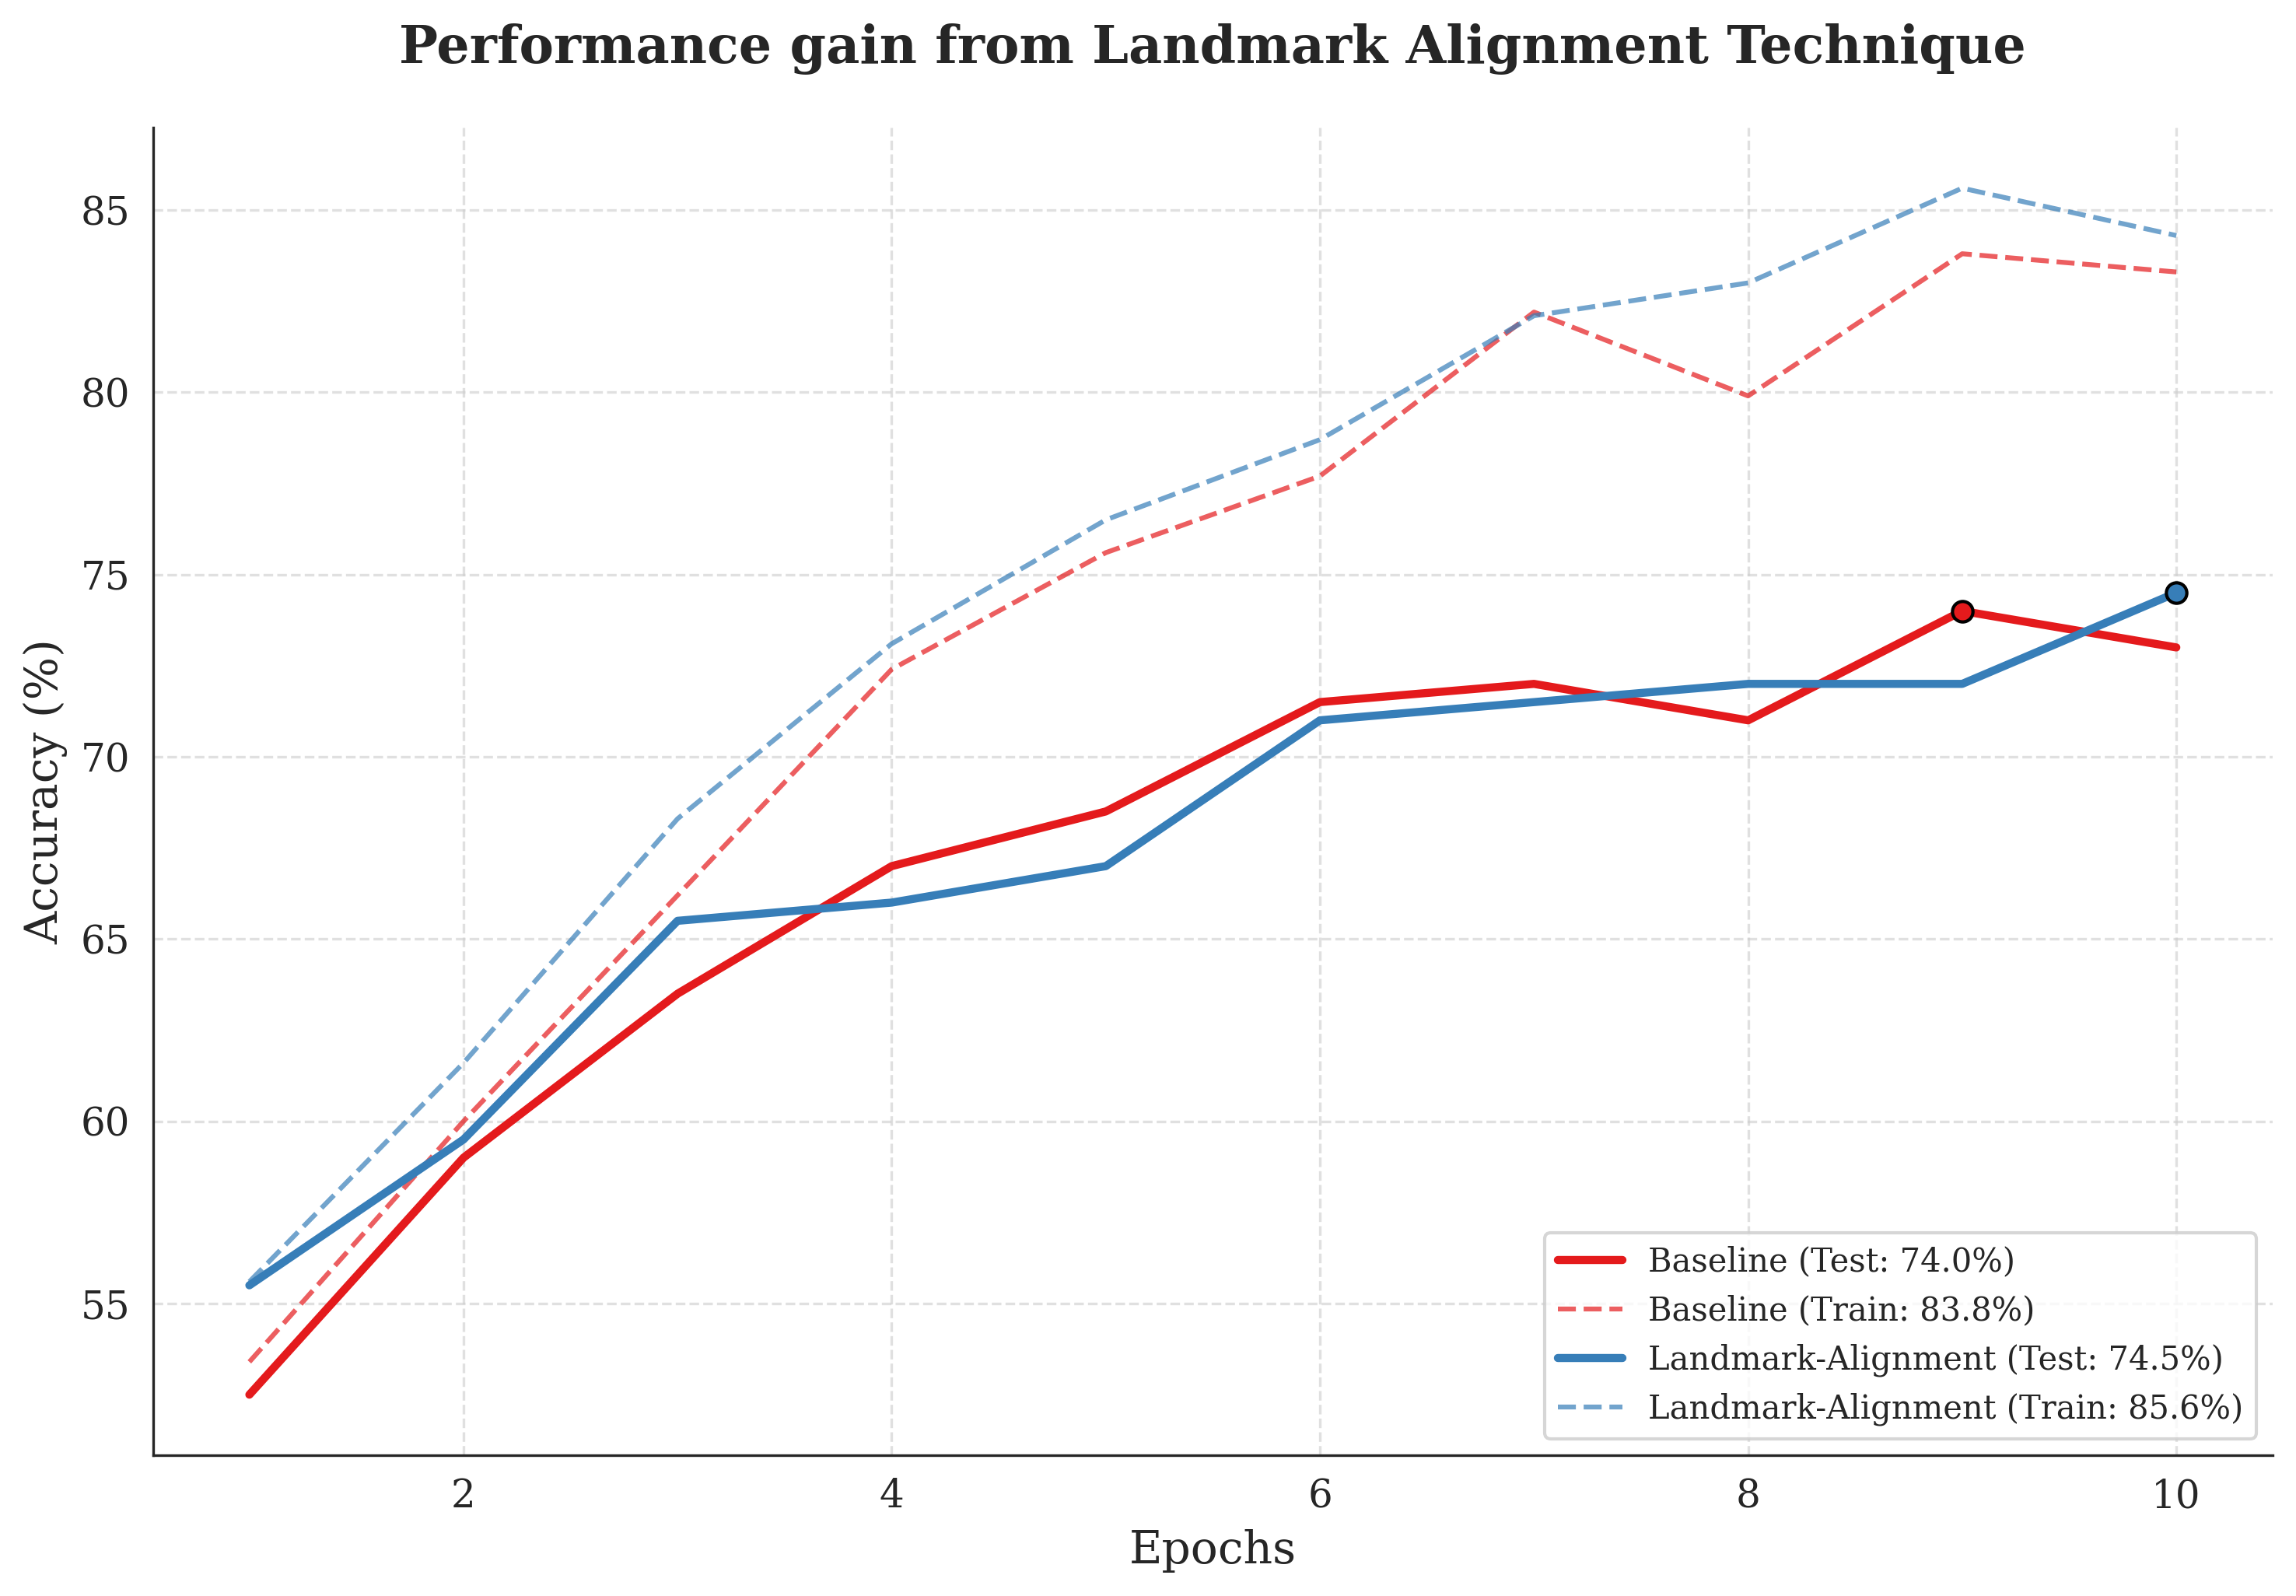

In [17]:
if results_log:
    plot_comparison(results_log)
else:
    print("Run the experiment cells first to populate results_log!")

From the above results, we can see that the Landmark Alignment technique provides a minimal boost in performance (~0.5% in test and 1.8% in train accuracy) compared to the baseline model. This suggests that aligning the faces based on facial landmarks helps the model focus on the relevant features and artifacts, leading to better generalization and improved performance on deepfake detection task.